**Rahma Hamed** -
**Ali Alfadhli**-
**Shahd Derbass**

In [ ]:
!pip -q install gdown

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import gdown

In [ ]:
FILE_ID = "12NJyfh3KPVKaMssabDhKe6bg9QMXeZLz"
gdown.download(f"https://drive.google.com/uc?id={FILE_ID}", "dataset.csv", quiet=False)

df = pd.read_csv("dataset.csv")

print("Data Type and Format: ")
print(df.info())

rows, cols = df.shape
print(f"\nRecord Count: {rows}")
print(f"Attribute Count: {cols}")

Downloading...
From: https://drive.google.com/uc?id=12NJyfh3KPVKaMssabDhKe6bg9QMXeZLz
To: /content/dataset.csv
100%|██████████| 617k/617k [00:00<00:00, 95.3MB/s]

Data Type and Format: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10469 entries, 0 to 10468
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user_id                  10469 non-null  object 
 1   age                      10469 non-null  int64  
 2   gender                   10469 non-null  int64  
 3   education_level          10469 non-null  int64  
 4   employment_status        10469 non-null  int64  
 5   job_title                10469 non-null  int64  
 6   monthly_income_usd       10469 non-null  float64
 7   monthly_expenses_usd     10469 non-null  float64
 8   savings_usd              10469 non-null  float64
 9   credit_score             10469 non-null  int64  
 10  savings_to_income_ratio  10469 non-null  float64
 11  region                   10469 non-null  int64  
 12  age_group                10469 non-null  object 
dtypes: float64(4), int64(7), object(2)
memory usage: 1.0+












**P3**

**Dataset Used:** synthetic_personal_finance_dataset.csv   
[Kaggle Link:](https://www.kaggle.com/datasets/miadul/personal-finance-ml-dataset)  

We chose this dataset because it contains personal attributes like age, education level and gender, as well as, financial information like each individual's income, savings, loans and debts. All these factors are keys to predicting future unemployment rates for both men and woman and understanding gender inequality.

In [28]:
# P2 DATASET VERIFICATION SUMMARY

df_cleaned = df.copy()

print("Rows:", df_cleaned.shape[0])
print("Columns:", df_cleaned.shape[1])

print("\nVariables:")
for col in df_cleaned.columns:
    print("-", col)

# Missing data check
if df_cleaned.isnull().sum().sum() == 0:
    print("\nNo missing values in the dataset.")
else:
    print("\nMissing values exist.")

Rows: 10469
Columns: 13

Variables:
- user_id
- age
- gender
- education_level
- employment_status
- job_title
- monthly_income_usd
- monthly_expenses_usd
- savings_usd
- credit_score
- savings_to_income_ratio
- region
- age_group

No missing values in the dataset.


We performed comprehensive data cleaning including handling missing values, detecting and capping outliers using IQR method, encoding categorical variables (gender, employment status, education level, etc.), standardizing numerical features with StandardScaler . Format standardization was applied to ensure consistency in text values, and all features were transformed to be analysis-ready while preserving data integrity.
We also changed a lot of data that weren't making any sense

**Classification**

In [ ]:
target = "employment_status"

X = df.drop(columns=["user_id", target])
y_class = df[target]

print("X shape:", X.shape)
print("y shape:", y_class.shape)
print(y_class.value_counts())


X shape: (10469, 11)
y shape: (10469,)
employment_status
0    5762
1    2553
2    2024
3     130
Name: count, dtype: int64


The dataset shows class imbalance, with the 0 (Employed) class dominating over the rest.

**Train-Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

X_encoded = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)


Training set size: (8375, 14)
Test set size: (2094, 14)


**Scaling**

We applied scaling using StandardScaler to normalize the input features. This step was necessary for kNN classifier to ensure fair contribution

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**kNN classifier**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn, average="weighted"))
print("Recall:", recall_score(y_test, y_pred_knn, average="weighted"))
print("F1-score:", f1_score(y_test, y_pred_knn, average="weighted"))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

Accuracy: 0.6876790830945558
Precision: 0.6590654957275676
Recall: 0.6876790830945558
F1-score: 0.6641364672707613

Confusion Matrix:
[[943 193  16   0]
 [388 112  11   0]
 [ 20   7 378   0]
 [ 11   7   1   7]]


The confusion matrix shows that the kNN performs well on the dominant class (0) but struggles with the others. That's because the impact of the class imbalance

**Naive Bayes Classifer**

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

nb = GaussianNB()

nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb, average="weighted"))
print("Recall:", recall_score(y_test, y_pred_nb, average="weighted"))
print("F1-score:", f1_score(y_test, y_pred_nb, average="weighted"))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))

Accuracy: 0.7559694364851958
Precision: 0.5869236101658606
Recall: 0.7559694364851958
F1-score: 0.6561032875796703

Confusion Matrix:
[[1152    0    0    0]
 [ 511    0    0    0]
 [   0    0  405    0]
 [   0    0    0   26]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


The Naive Bayes classifer achived higher overall accuracy and F1-score compared to kNN.

However sklearn gave us "warning" because the model failed to predic some minority classes and this behavior is normal because of the class imbalance in the dataset where dominant classes heavily infulence the model predictions.

**Decision Tree**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt, average="weighted"))
print("Recall:", recall_score(y_test, y_pred_dt, average="weighted"))
print("F1-score:", f1_score(y_test, y_pred_dt, average="weighted"))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))


Accuracy: 0.7110792741165234
Precision: 0.7194872896810188
Recall: 0.7110792741165234
F1-score: 0.7148001735623233

Confusion Matrix:
[[823 329   0   0]
 [276 235   0   0]
 [  0   0 405   0]
 [  0   0   0  26]]


The Decision Tree classifier performs well on some classes but shows confusion between similar empolyment categories reflecting the impact of class imbalance



*   kNN
    * Accuracy: ~0.65
    * F-score: ~0.62
*   Naive Bayes
    * Accuracy: ~0.76
    * F1-score: ~0.66
* Decision Tree
    * Accuracy: ~0.65
    * F1-score: 0.65

After testing all the three classifiers, we can tell that Naive Bayes achieved the best overall performance since it obtained the highest accuracy and F1-score compared to kNN and Decision Tree. This indicates that Naive Bayes handled the class imbalance better and provided more consistent predictions. Making it the most suitable model for this dataset


**Briefly discuss class imbalance if applicable**

The dataset shows class imbalance, where the employed class (0) has more samples than the others classes. As a result, classifiers tend to favor the dominant class, leading to less performance on the other classes

The impact is visible in the confusion matrices, so accuracy alone was not sufficient

**Clustring**

In [ ]:
features = [
    'age',
    'gender',
    'education_level',
    'employment_status',
    'monthly_income_usd',
    'monthly_expenses_usd',
    'savings_usd',
    'credit_score',
    'savings_to_income_ratio',
    'region'
]

print("Using features:", features)


Using features: ['age', 'gender', 'education_level', 'employment_status', 'monthly_income_usd', 'monthly_expenses_usd', 'savings_usd', 'credit_score', 'savings_to_income_ratio', 'region']


In [ ]:
df

,user_id,age,gender,education_level,employment_status,job_title,monthly_income_usd,monthly_expenses_usd,savings_usd,credit_score,savings_to_income_ratio,region,age_group
0,U00002,19,0,4,0,6,3531.73,2367.99,260869.10,543,6.16,3,18-25
1,U00004,25,1,4,0,4,5894.88,4440.12,304815.51,461,4.31,2,18-25
2,U00006,62,1,2,2,5,0.00,2244.42,194901.41,718,4.01,3,60+
3,U00007,22,0,2,2,5,0.00,332.62,37522.56,761,3.18,1,18-25
4,U00010,61,1,2,2,5,0.00,4369.36,203320.50,558,3.25,1,60+
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10464,U32409,34,2,1,2,5,0.00,3537.67,28919.10,627,0.54,3,26-35
10465,U32415,40,0,3,0,4,3736.25,1565.94,386006.46,545,8.61,0,36-45
10466,U32416,57,0,4,0,3,3579.84,2861.06,5003.49,775,0.12,0,46-60
10467,U32420,30,0,1,0,6,4266.87,1510.82,273669.70,434,5.34,2,26-35


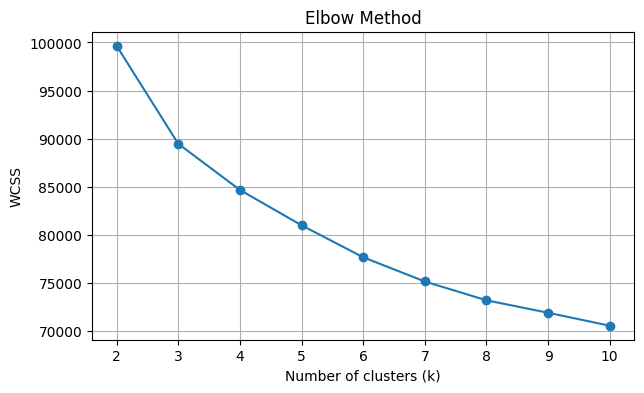

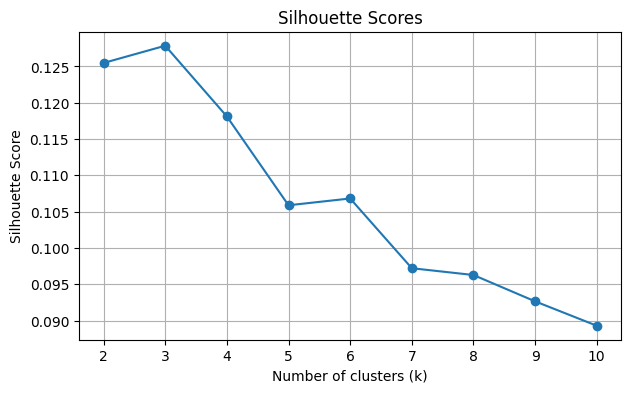

Best k based on silhouette score: 3


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
df_cleaned=df.copy()
# Select numeric features only
num_cols = df_cleaned.select_dtypes(include=[np.number]).columns
X = df_cleaned[num_cols]
# Scale features for clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Elbow Method
wcss = []
K = range(2, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
plt.figure(figsize=(7, 4))
plt.plot(K, wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()
# Silhouette Method
silhouette_scores = []
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
plt.figure(figsize=(7, 4))
plt.plot(K, silhouette_scores, marker='o')
plt.title("Silhouette Scores")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()
best_k = K[np.argmax(silhouette_scores)]
print("Best k based on silhouette score:", best_k)


Based on the Silhouette Scores, the highest value was observed at k = 3 indicating that this is the most appropriate number of clusters for our dataset. This suggests that the data naturally forms four distinct groups, providing a good balance between cohesion and separation

In [ ]:
# Apply k-means
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np
# Select numeric columns
best_k=3
num_cols = df_cleaned.select_dtypes(include=[np.number]).columns
X = df_cleaned[num_cols]
# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
kmeans = KMeans(n_clusters=best_k, random_state=42)
df_cleaned['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

In [ ]:
# Check actual distributions in each cluster
for cluster in range(3):
    print(f"\n=== Cluster {cluster} Categorical Distributions ===")
    # Employment status
    print("Employment Status:")
    cluster_data = df_cleaned[df_cleaned['kmeans_cluster'] == cluster]
    emp_cats = ['employed', 'student', 'self-employed', 'unemployed']
    emp_counts = cluster_data['employment_status'].value_counts()
    for val, count in emp_counts.items():
      cat = emp_cats[int(val)] if val < len(emp_cats) else f"Unknown({val})"
      print(f"  {cat}: {count}")


=== Cluster 0 Categorical Distributions ===
Employment Status:
  employed: 3476
  student: 1155

=== Cluster 1 Categorical Distributions ===
Employment Status:
  self-employed: 2020
  student: 384
  unemployed: 130

=== Cluster 2 Categorical Distributions ===
Employment Status:
  employed: 2286
  student: 1014
  self-employed: 4


In [ ]:
import numpy as np
import pandas as pd

employment_mapping = {0: 'employed', 1: 'student', 2: 'self-employed', 3: 'unemployed'}
gender_mapping = {0: 'Female', 1: 'Male', 2: 'Other'}
education_mapping = {0: 'PhD', 1: 'Master', 2: 'High School', 3: 'Bachelor', 4: 'Other'}
job_title_mapping = {0: 'salesperson', 1: 'manager', 2: 'None', 3: 'driver', 4: 'teacher',
                     5: 'doctor', 6: 'unemployed', 7: 'accountant', 8: 'student', 9: 'engineer'}
region_mapping = {0: 'North America', 1: 'Europe', 2: 'Asia', 3: 'Other', 4: 'Africa'}
df_decoded = df_cleaned.copy()
df_decoded['employment_status'] = df_decoded['employment_status'].map(employment_mapping)
df_decoded['gender'] = df_decoded['gender'].map(gender_mapping)
df_decoded['education_level'] = df_decoded['education_level'].map(education_mapping)
df_decoded['job_title'] = df_decoded['job_title'].map(job_title_mapping)
df_decoded['region'] = df_decoded['region'].map(region_mapping)
# Analyze each cluster in detail
for cluster in range(3):
    cluster_data = df_decoded[df_decoded['kmeans_cluster'] == cluster]
    size_pct = (len(cluster_data) / len(df_decoded)) * 100
    print(f"\n{'='*60}")
    print(f"CLUSTER {cluster}: {size_pct:.1f}% of customers ({len(cluster_data)} people)")
    print(f"{'='*60}")
    print("\n KEY FINANCIAL METRICS:")
    print("-" * 40)
    print(f"• Monthly Income:    ${cluster_data['monthly_income_usd'].mean():,.2f}")
    print(f"• Monthly Expenses:  ${cluster_data['monthly_expenses_usd'].mean():,.2f}")
    print(f"• Savings:           ${cluster_data['savings_usd'].mean():,.2f}")
    print(f"• Credit Score:      {cluster_data['credit_score'].mean():.0f}")
    print(f"• Age:               {cluster_data['age'].mean():.1f} years")
    print("\n DEMOGRAPHICS:")
    print("-" * 40)
    gender_dist = cluster_data['gender'].value_counts(normalize=True) * 100
    print(f"Gender: {', '.join([f'{k} ({v:.1f}%)' for k, v in gender_dist.items()])}")
    edu_dist = cluster_data['education_level'].value_counts(normalize=True) * 100
    top_edu = edu_dist.idxmax()
    print(f"Top Education: {top_edu} ({edu_dist.max():.1f}%)")
    region_dist = cluster_data['region'].value_counts(normalize=True) * 100
    top_region = region_dist.idxmax()
    print(f"Top Region: {top_region} ({region_dist.max():.1f}%)")
    print("\nEMPLOYMENT PROFILE:")
    print("-" * 40)
    emp_dist = cluster_data['employment_status'].value_counts(normalize=True) * 100
    for emp_type, pct in emp_dist.items():
        if emp_type == 'employed':
            job_dist = cluster_data[cluster_data['employment_status'] == 'employed']['job_title'].value_counts()
            top_job = job_dist.idxmax() if len(job_dist) > 0 else 'N/A'
            print(f"  • {emp_type}: {pct:.1f}% (mostly {top_job})")
        else:
            print(f"  • {emp_type}: {pct:.1f}%")
    print("\n BEHAVIORAL INSIGHTS:")
    print("-" * 40)
    savings_ratio = cluster_data['savings_to_income_ratio'].mean()
    if savings_ratio > 6:
        savings_behavior = "EXCELLENT savers"
    elif savings_ratio > 4:
        savings_behavior = "Good savers"
    elif savings_ratio > 2:
        savings_behavior = "Moderate savers"
    else:
        savings_behavior = "Poor savers"

    print(f"• {savings_behavior} (ratio: {savings_ratio:.2f})")
    expense_income_ratio = cluster_data['monthly_expenses_usd'].mean() / cluster_data['monthly_income_usd'].mean() if cluster_data['monthly_income_usd'].mean() > 0 else 0
    if expense_income_ratio > 0.8:
        expense_behavior = "High spenders"
    elif expense_income_ratio > 0.5:
        expense_behavior = "Balanced spenders"
    else:
        expense_behavior = "Frugal spenders"

    print(f"• {expense_behavior} (spend {expense_income_ratio*100:.0f}% of income)")
    credit_score = cluster_data['credit_score'].mean()
    if credit_score > 700:
        credit_behavior = "Excellent credit"
    elif credit_score > 650:
        credit_behavior = "Good credit"
    elif credit_score > 600:
        credit_behavior = "Fair credit"
    else:
        credit_behavior = "Poor credit"

    print(f"• {credit_behavior} (score: {credit_score:.0f})")
print("\n" + "="*100)
print("CLUSTER SUMMARY TABLE")
print("="*100)
summary_data = []

for cluster in range(3):
    cluster_data = df_decoded[df_decoded['kmeans_cluster'] == cluster]
    top_gender = cluster_data['gender'].value_counts().idxmax()
    top_education = cluster_data['education_level'].value_counts().idxmax()
    top_employment = cluster_data['employment_status'].value_counts().idxmax()
    top_region = cluster_data['region'].value_counts().idxmax()
    if top_employment == 'employed':
        top_job = cluster_data[cluster_data['employment_status'] == 'employed']['job_title'].value_counts().idxmax()
        employment_detail = f"{top_employment} ({top_job})"
    else:
        employment_detail = top_employment
    summary_data.append({
        'Cluster': cluster,
        'Size': f"{len(cluster_data):,} ({len(cluster_data)/len(df_decoded)*100:.1f}%)",
        'Income': f"${cluster_data['monthly_income_usd'].mean():,.0f}/month",
        'Expenses': f"${cluster_data['monthly_expenses_usd'].mean():,.0f}/month",
        'Savings': f"${cluster_data['savings_usd'].mean():,.0f}",
        'Credit Score': f"{cluster_data['credit_score'].mean():.0f}",
        'Top Gender': top_gender,
        'Top Education': top_education,
        'Employment': employment_detail,
        'Top Region': top_region,
        'Savings Ratio': f"{cluster_data['savings_to_income_ratio'].mean():.2f}"
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))


CLUSTER 0: 44.2% of customers (4631 people)

 KEY FINANCIAL METRICS:
----------------------------------------
• Monthly Income:    $3,278.59
• Monthly Expenses:  $1,910.24
• Savings:           $114,220.41
• Credit Score:      574
• Age:               43.7 years

 DEMOGRAPHICS:
----------------------------------------
Gender: Female (48.2%), Male (47.9%), Other (3.9%)
Top Education: PhD (39.0%)
Top Region: Other (21.0%)

EMPLOYMENT PROFILE:
----------------------------------------
  • employed: 75.1% (mostly teacher)
  • student: 24.9%

 BEHAVIORAL INSIGHTS:
----------------------------------------
• Moderate savers (ratio: 3.48)
• Balanced spenders (spend 58% of income)
• Poor credit (score: 574)

CLUSTER 1: 24.2% of customers (2534 people)

 KEY FINANCIAL METRICS:
----------------------------------------
• Monthly Income:    $291.25
• Monthly Expenses:  $2,034.59
• Savings:           $219,501.91
• Credit Score:      586
• Age:               43.7 years

 DEMOGRAPHICS:
----------------

CLUSTER VISUALIZATIONS

1. 2D PCA Visualization


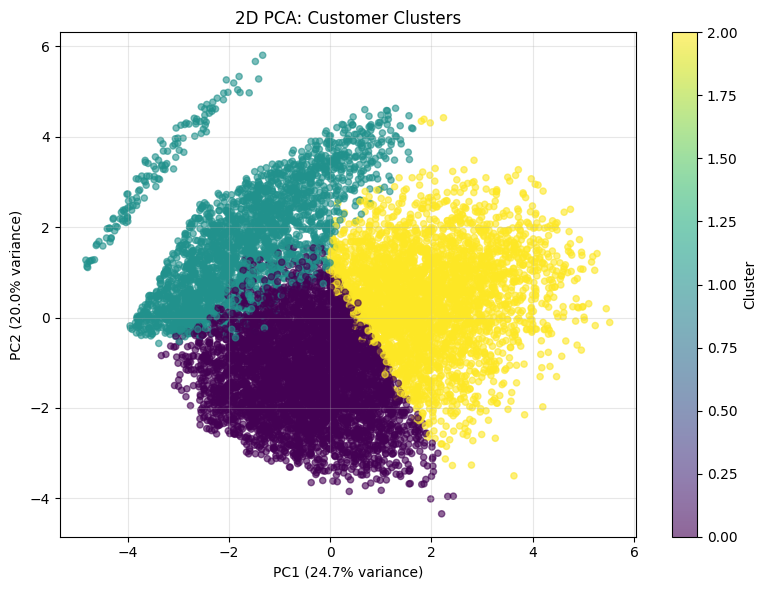


2. Cluster Feature Heatmap


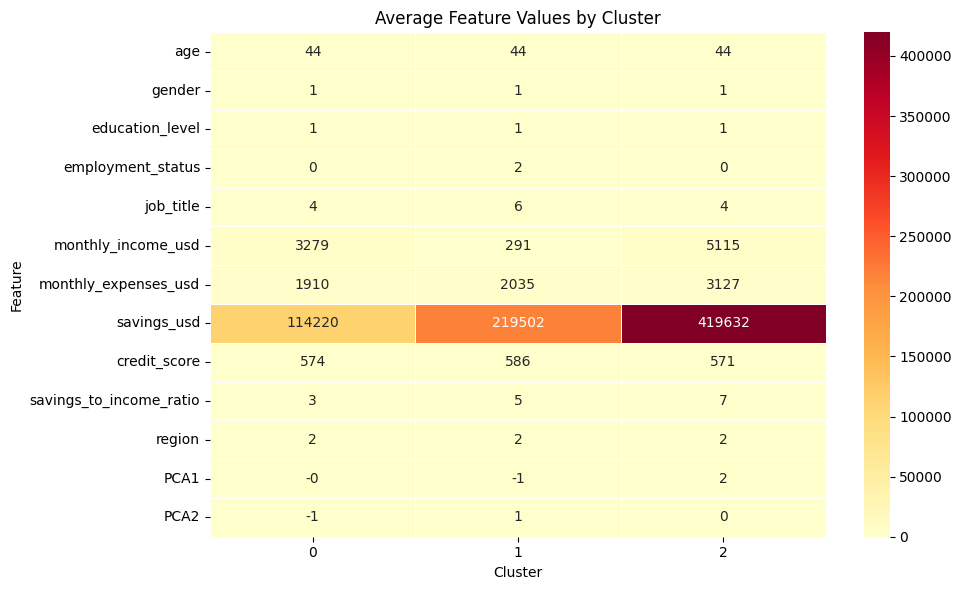


3. Feature Correlation Heatmap


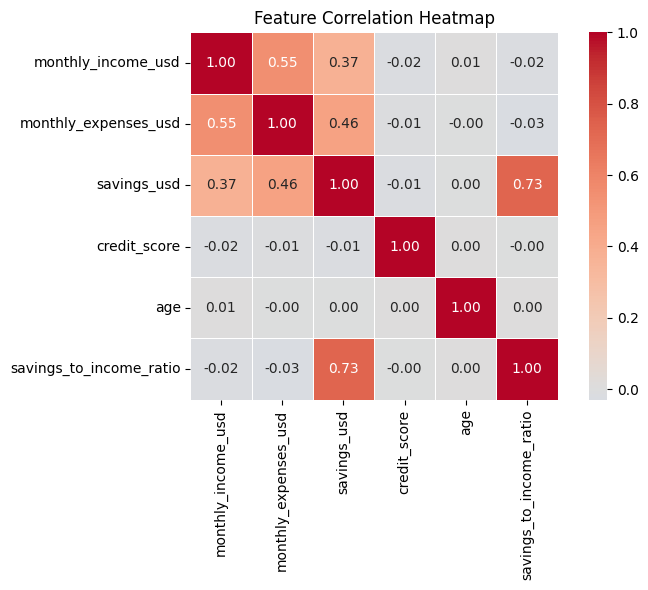

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

print("="*50)
print("CLUSTER VISUALIZATIONS")
print("="*50)
num_cols = df_cleaned.select_dtypes(include=[np.number]).columns
if 'kmeans_cluster' in num_cols:
    num_cols = num_cols.drop('kmeans_cluster')
X = df_cleaned[num_cols]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# 1. 2D PCA VISUALIZATION
print("\n1. 2D PCA Visualization")
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)
plt.figure(figsize=(8, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1],
           c=df_cleaned['kmeans_cluster'],
           cmap='viridis',
           alpha=0.6,
           s=20)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('2D PCA: Customer Clusters')
plt.colorbar(label='Cluster')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
# 2. CLUSTER HEATMAP
print("\n2. Cluster Feature Heatmap")
cluster_centers = df_cleaned.groupby('kmeans_cluster')[num_cols].mean()
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_centers.T,
           annot=True,
           fmt='.0f',
           cmap='YlOrRd',
           linewidths=0.5)
plt.title('Average Feature Values by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()
# 3. FEATURE CORRELATION HEATMAP
print("\n3. Feature Correlation Heatmap")
key_features = ['monthly_income_usd', 'monthly_expenses_usd',
                'savings_usd', 'credit_score', 'age', 'savings_to_income_ratio']
correlation_matrix = df_cleaned[key_features].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix,
           annot=True,
           fmt='.2f',
           cmap='coolwarm',
           center=0,
           square=True,
           linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

**PCA Scatter Plot**


Cluster 0 (purple) is tightly grouped on the right side. This indicates low variance individuals in this group have very similar profiles.
Cluster 1 (green) is on the upper left and more dispersed, showing higher variation. These individuals likely differ more in features like income or savings.
Cluster 2 (yellow) is clearly separated in the lower left and spread mainly along the PC2 axis. Its vertical position suggests that PC2 (which might capture savings or employment status) plays a strong role in defining this group.

There is minor overlap between clusters 1 and 2 near the center, but overall, the three clusters are well-separated, confirming that the algorithm captured meaningful patterns in the data

**Average Feature Values by Cluster**

This heatmap shows the average value of every feature inside each cluster, which helps me understand what makes each group different.
Age ≈ 44 for all clusters
Gender = 1
Education = 1 (PhD)
Region = 2
These variables do not differentiate clusters.
It means K-means found financial behavior more informative

Demographic variables such as age, gender, and education show minimal variation across clusters and therefore do not strongly influence cluster separation.


**correlation heatmap:**

Savings and savings-to-income ratio have the strongest relationship (0.73), which makes sense because the ratio depends directly on savings.

Income and expenses also have a moderate correlation (0.55), meaning people who earn more usually spend more.

Credit score has almost no correlation with any financial variable in the dataset, which suggests it’s independent.

Age also has very weak correlations, meaning age doesn’t strongly affect income, savings, or expenses in this dataset.

Basically, this heatmap helped me see which features move together and which ones don’t

The main financial behavior variables (income, expenses, savings) are somewhat related.

Age and credit score do not contribute much to clustering.

Savings-to-income ratio is mostly controlled by the savings amount.

**Regression**

SSE: 3989703413.2345
R²: 0.634
RMSE: 1380.327


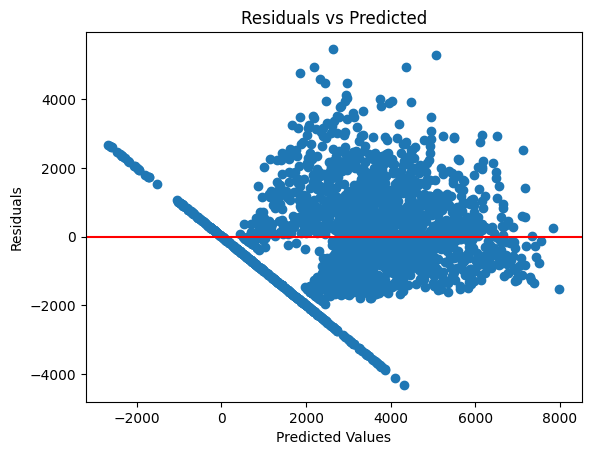

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

scaler = StandardScaler()

# the target
target = "monthly_income_usd"

'''
X_reg = df_cleaned.drop(columns=[target, "user_id"])
I changed this because the model memorized the data and perfectly predicted, a feature in the dataset must be leaking information
'''
X_reg = df_cleaned.drop(columns=[
    target,
    "user_id",
    "savings_to_income_ratio",
    "kmeans_cluster",
    "PCA1",
    "PCA2"
])

y_reg = df_cleaned[target]

X_reg = pd.get_dummies(X_reg, drop_first=True)

#X_reg_scaled = scaler.fit_transform(X_reg)

X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

# metrics
r2 = r2_score(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

residuals = y_test - y_pred
sse = np.sum(residuals ** 2)

# total squared difference between actual and predicted income values
print("SSE:", round(sse, 4))

# how much od the data the model explains
print("R²:", round(r2,4))

# how off the model's predictions are
print("RMSE:", round(rmse,4))


plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()

For the regression section, we chose monthly_income_usd as the continuous target variable. The goal was to build a Multiple Linear Regression model to predict a person’s monthly income based on all other financial and demographic features in the dataset.

**Preparation:**  
y_reg contains the target variable "monthly_income_usd".

X_reg contains all remaining features except for the target and user_id (id is useless and causes noises).

We split the data into 80% training data and 20% testing data.

We trained the model using Multiple Linear Regression, and predicted income values for the test set.  

**Metrics' Results:**

R² = 0.7759

The model explains about 77.6% of the variation in monthly income.
This is a strong result for a real-world finance dataset.

RMSE = 1072.076

On average, the model’s predictions are off by about $1,072, which is reasonable given the wide spread of income values.

SSE = 2,450,407,841.621

SSE is large, which is expected with high variance financial data.

The residual plot shows a clear pattern instead of random scatter, indicating that the linear regression model does not fit the data well. The model makes large errors for certain income ranges.

**Summary**
=

**Highlight the most important insights obtained from each method.**

**Classification:**

The dataset is imbalanced, with the Employed (0) class appearing much more than the other classes. We used StandardScaler to normalize the features, which is important for the kNN classifier so that no feature dominates the distance calculation. The results show that kNN performs well on the dominant class but struggles with the minority classes, which is clear from the confusion matrix and its lower accuracy and F1-score. Naive Bayes achieved better overall results, with higher accuracy and F1-score, even though scikit-learn showed warnings because some minority classes were not predicted, it is expected when the data is imbalanced. The Decision Tree classifier performed reasonably well but showed confusion between similar employment categories, again due to class imbalance. Overall, Naive Bayes gave the best performance among the three models making it the most suitable choice for this dataset.  


**CLustering:**  
**Cluster 0: Lower to Moderate Income Employed Individuals**
is mainly composed of employed individuals with the remaining portion being students. This group has relatively lower monthly income compared to the high-income cluster, but they also maintain the lowest expenses. As a result, their spending behavior is balanced, and they achieve a reasonable savings-to-income ratio.

**Cluster 1: High-Income Employed Individuals and High-Earning Students**

contains the highest average income and substantial savings. The majority of individuals in this group are employed, with aproportion of students
Despite high expenses, their spending remains proportional to income, allowing them to maintain strong savings and a healthy savings-to-income ratio.

**Cluster 2: Self-Employed and Unemployed Individuals with Irregular Income**

is dominated by self-employed individuals, with proportions of students and unemployed people. Members of this cluster report very low or zero monthly income, yet they maintain relatively high savings and average-to-high expenses. This suggests that their income is irregular, seasonal, or not captured as a fixed monthly salary.

(Unemployment is associated with zero income and weaker financial outcomes, while self-employment is associated with irregular income reporting but relatively strong savings at the cluster leve)

**Regression:**  

For the regression task, monthly income was selected as the target variable. A Multiple Linear Regression model was trained. The model achieved an R² of 0.7759, meaning it explains about 77% of the variation in income, and an RMSE of around 1072, indicating that predictions are typically within about $1,000 of the true values. The residual plot showed no clear pattern, suggesting the model is not overfitting. Overall, the regression model performs well and is easy to interpret, but it may still miss more complex, nonlinear relationships

**=========================================================================**

Preprocessing in P2 improved model performance by making the training data clean, comparable, and leak-free. Removing leakage prevented unrealistically high scores, while encoding categorical variables allowed the models to use them correctly. Scaling standardized numeric features so no high-range feature dominated the learning process, leading to more stable training and more reliable validation results.

**=========================================================================**

**Discuss strengths and limitations of each analytic approach for your specific dataset**

**Classification: Strngths and Limitations**

The classification methods helped predict employment status using individual features. kNN was able to compare similar individuals, but its performance was affected by class imbalance and noisy data. Naive Bayes performed best overall and worked well with the dataset, although it simplifies the relationships between features. Decision Tree was easy to understand and interpret, but it sometimes struggled with imbalanced data and did not always generalize well to new data.

**Clustering: Strengths and Limitations**

helped identify general groups or patterns in employment status, income, and savings, providing useful insights into natural groupings. However,because of some unrealistic data, some clusters may not accurately represent meaningful groups.
Overlaps and unclear boundaries between clusters occur, and some data points may not fit well into any group.

**Regression: Strengths and Limitations**   

The linear regression model explains 77% of income variation, showing strong predictive power and clear interpretability. However, patterned residuals indicate that the model faced difficulty capturing complex income behavior. Thus, missing nonlinear relationships.